In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_aod_heatmap_by_date(csv_path, date_str):
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    
    date_only = pd.to_datetime(date_str).date()
    df_filtered = df[df['datetime'].dt.date == date_only]

    if df_filtered.empty:
        print(f"Tidak ada data untuk tanggal: {date_str}")
        return

    grid_lon = np.linspace(df_filtered['Longitude'].min(), df_filtered['Longitude'].max(), 200)
    grid_lat = np.linspace(df_filtered['Latitude'].min(), df_filtered['Latitude'].max(), 200)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    grid_aod = griddata(
        points=(df_filtered['Longitude'], df_filtered['Latitude']),
        values=df_filtered['AOD'],
        xi=(grid_lon, grid_lat),
        method='cubic'
    )

    plt.figure(figsize=(10, 8))
    contour = plt.contourf(grid_lon, grid_lat, grid_aod, levels=100, cmap='YlOrRd')
    plt.colorbar(contour, label='AOD')
    plt.title(f"AOD Heatmap \nTanggal: {date_str}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


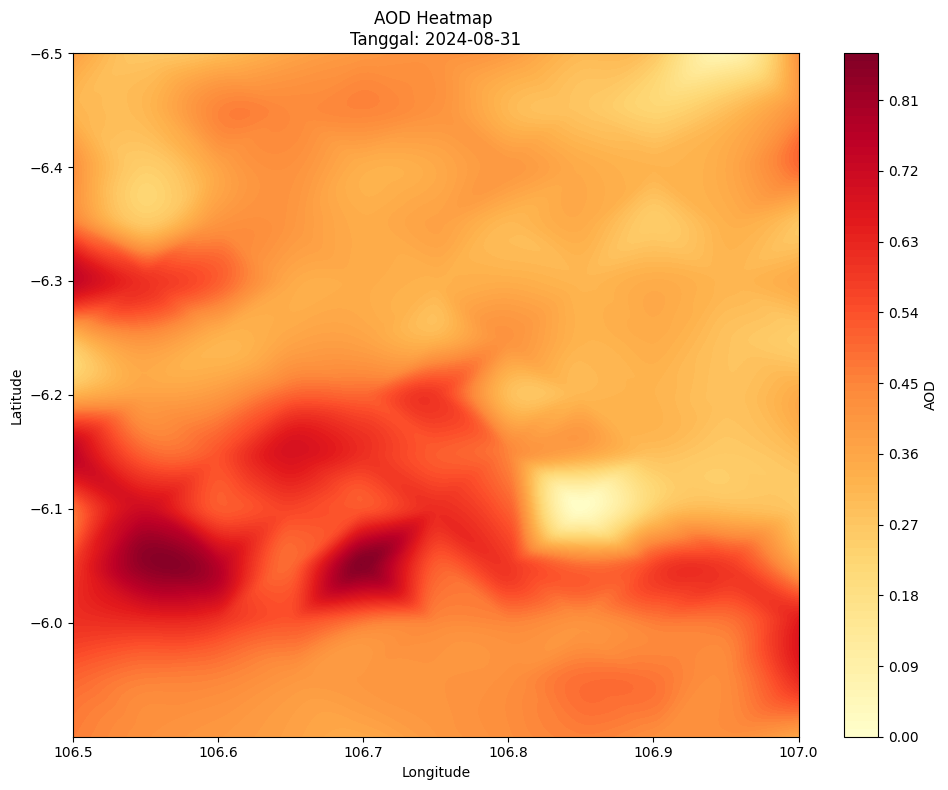

In [3]:
plot_aod_heatmap_by_date("merged_himawari.csv", "2024-08-31")


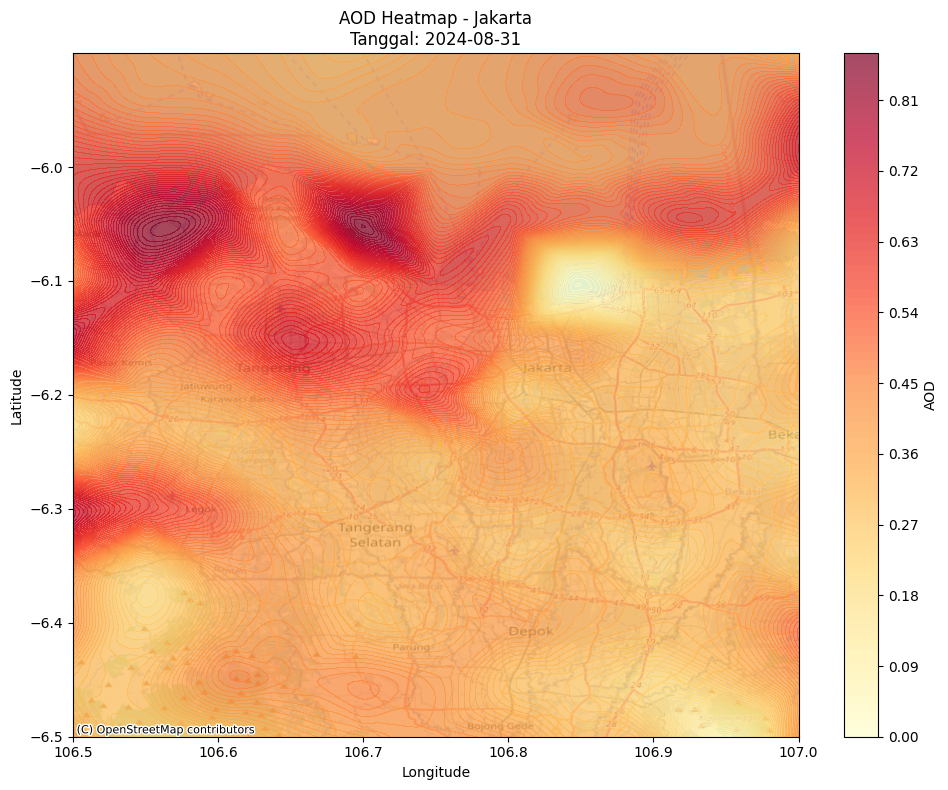

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import contextily as ctx

def plot_aod_heatmap_with_map_full(csv_path, date_str):
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

    date_only = pd.to_datetime(date_str).date()
    df_filtered = df[df['datetime'].dt.date == date_only]

    if df_filtered.empty:
        print(f"Tidak ada data untuk tanggal: {date_str}")
        return

    grid_lon = np.linspace(df_filtered['Longitude'].min(), df_filtered['Longitude'].max(), 300)
    grid_lat = np.linspace(df_filtered['Latitude'].min(), df_filtered['Latitude'].max(), 300)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    grid_aod = griddata(
        points=(df_filtered['Longitude'], df_filtered['Latitude']),
        values=df_filtered['AOD'],
        xi=(grid_lon, grid_lat),
        method='cubic'
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    # Tampilkan heatmap penuh (cubic)
    contour = ax.contourf(
        grid_lon, grid_lat, grid_aod,
        levels=100, cmap='YlOrRd', alpha=0.7
    )

    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_xlim(df_filtered['Longitude'].min(), df_filtered['Longitude'].max())
    ax.set_ylim(df_filtered['Latitude'].min(), df_filtered['Latitude'].max())

    cbar = plt.colorbar(contour, ax=ax, label='AOD')
    ax.set_title(f"AOD Heatmap - Jakarta\nTanggal: {date_str}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.show()

plot_aod_heatmap_with_map_full("merged_himawari.csv", "2024-08-31")
